# Partial Reproduction Notebook — *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles* (Lakshminarayanan et al., 2017)

This Colab-ready notebook reproduces several of the paper's main ideas and experimental results:

1. **Toy regression uncertainty experiment** using deep ensembles
2. **MNIST ensemble classification experiment**
3. **Predictive uncertainty analysis** using entropy on in-distribution and out-of-distribution data
4. **Effect of ensemble size** on classification error, negative log-likelihood (NLL), and Brier score

The notebook follows the core methodology proposed in the paper: independently training multiple probabilistic neural networks and combining their predictions to obtain improved predictive performance and uncertainty estimates.

This remains a **partial reproduction** of the paper. In particular, we do not reproduce the large-scale benchmarks (e.g., SVHN or ImageNet), adversarial training experiments, or comparisons with MC-Dropout. Instead, we focus on four representative experiments that capture the main ideas and conclusions of the original work.

## Method summary

The paper proposes a simple recipe for predictive uncertainty estimation with neural networks:

- train **probabilistic neural networks**
- use a **proper scoring rule**
- train several networks independently
- average their predictive distributions at test time

For regression, each network predicts a mean and variance.  
For classification, each network predicts class probabilities.

In [49]:
import os, math, random, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Part 1 — Toy regression uncertainty

We create a small noisy cubic dataset and train an ensemble of probabilistic regressors.
Each regressor predicts:

- \(\mu(x)\)
- \(\sigma^2(x)\)

and is trained with Gaussian negative log-likelihood.

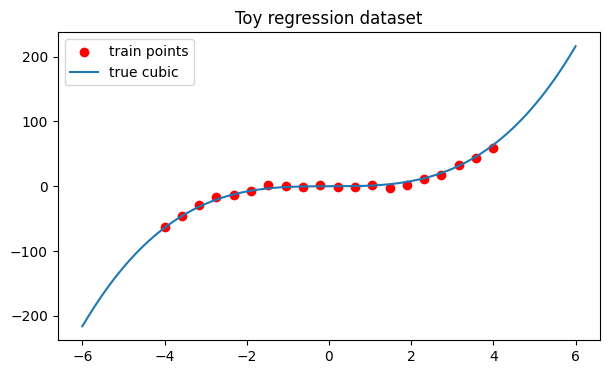

In [50]:
N_train = 20
x_train = np.linspace(-4, 4, N_train).reshape(-1, 1)
y_train = x_train**3 + np.random.normal(0, 3.0, size=x_train.shape)

x_plot = np.linspace(-6, 6, 400).reshape(-1, 1)
y_true_plot = x_plot**3

x_train_t = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32).to(device)

plt.figure(figsize=(7,4))
plt.scatter(x_train, y_train, color="red", label="train points")
plt.plot(x_plot, y_true_plot, label="true cubic")
plt.title("Toy regression dataset")
plt.legend()
plt.show()

In [51]:
class ProbabilisticRegressor(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden, 1)
        self.logvar_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        mean = self.mean_head(h)
        var = F.softplus(self.logvar_head(h)) + 1e-6
        return mean, var

def gaussian_nll(y, mean, var):
    return 0.5 * torch.mean(torch.log(var) + (y - mean) ** 2 / var)

def train_prob_regressor(model, x, y, epochs=1500, lr=1e-3, weight_decay=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        mean, var = model(x)
        loss = gaussian_nll(y, mean, var)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

def ensemble_regression_predict(models, x):
    means, vars_ = [], []
    for model in models:
        model.eval()
        with torch.no_grad():
            m, v = model(x)
            means.append(m.cpu().numpy())
            vars_.append(v.cpu().numpy())
    means = np.stack(means, axis=0)
    vars_ = np.stack(vars_, axis=0)
    ensemble_mean = means.mean(axis=0)
    ensemble_var = (vars_ + means**2).mean(axis=0) - ensemble_mean**2
    return ensemble_mean.squeeze(), np.sqrt(np.maximum(ensemble_var.squeeze(), 1e-12))

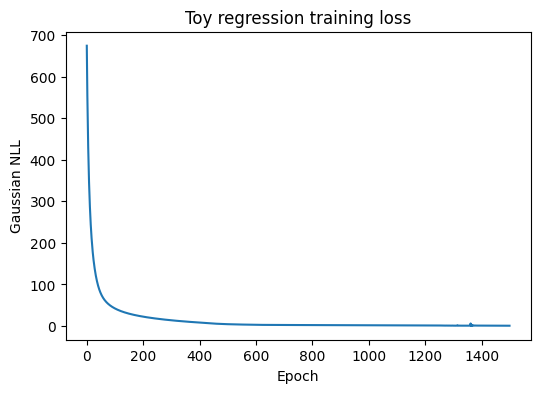

In [52]:
M_reg = 5
reg_models, reg_histories = [], []

for i in range(M_reg):
    torch.manual_seed(SEED + i)
    model = ProbabilisticRegressor(hidden=64).to(device)
    losses = train_prob_regressor(model, x_train_t, y_train_t, epochs=1500, lr=1e-3, weight_decay=1e-4)
    reg_models.append(model)
    reg_histories.append(losses)

plt.figure(figsize=(6,4))
plt.plot(reg_histories[0])
plt.title("Toy regression training loss")
plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL")
plt.show()

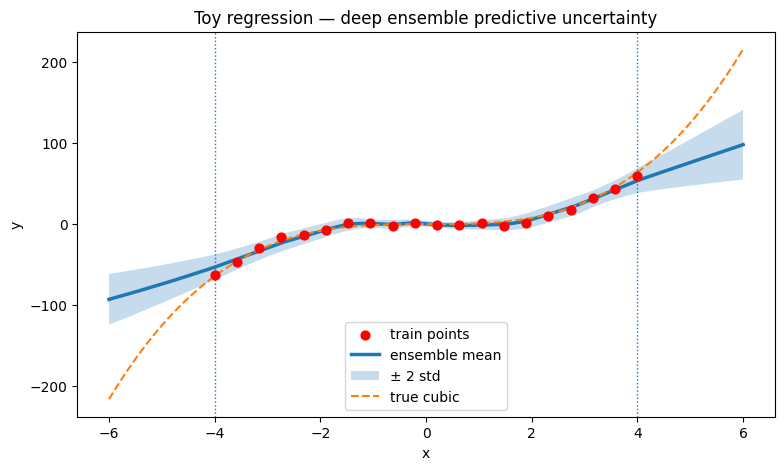

In [53]:
ens_mean, ens_std = ensemble_regression_predict(reg_models, x_plot_t)

plt.figure(figsize=(9,5))
plt.scatter(x_train, y_train, color="red", s=40, label="train points", zorder=3)
plt.plot(x_plot, ens_mean, linewidth=2.5, label="ensemble mean")
plt.fill_between(
    x_plot.squeeze(),
    ens_mean - 2 * ens_std,
    ens_mean + 2 * ens_std,
    alpha=0.25,
    label="± 2 std"
)
plt.plot(x_plot, y_true_plot, linestyle="--", linewidth=1.5, label="true cubic")
plt.axvline(x_train.max(), linestyle=":", linewidth=1)
plt.axvline(x_train.min(), linestyle=":", linewidth=1)
plt.title("Toy regression — deep ensemble predictive uncertainty")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Part 2 — MNIST ensemble experiment

We train several MLP classifiers independently on MNIST and compare:

- accuracy
- negative log-likelihood
- Brier score
- predictive entropy

In [54]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
ood_dataset   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)  # proxy OOD

train_subset_size = 20000
test_subset_size = 5000
ood_subset_size = 5000

train_indices = np.random.RandomState(SEED).choice(len(train_dataset), train_subset_size, replace=False)
test_indices  = np.random.RandomState(SEED+1).choice(len(test_dataset), test_subset_size, replace=False)
ood_indices   = np.random.RandomState(SEED+2).choice(len(ood_dataset), ood_subset_size, replace=False)

train_subset = Subset(train_dataset, train_indices)
test_subset  = Subset(test_dataset, test_indices)
ood_subset   = Subset(ood_dataset, ood_indices)

batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
ood_loader   = DataLoader(ood_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train subset:", len(train_subset))
print("Test subset:", len(test_subset))
print("OOD subset :", len(ood_subset))

Train subset: 20000
Test subset: 5000
OOD subset : 5000


In [55]:
class MNISTMLP(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 10),
        )

    def forward(self, x):
        return self.net(x)

def train_classifier(model, train_loader, epochs=5, lr=1e-3, weight_decay=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"loss": [], "acc": []}
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        history["loss"].append(running_loss / total)
        history["acc"].append(correct / total)
        print(f"Epoch {epoch+1}/{epochs} - loss={history['loss'][-1]:.4f} - acc={history['acc'][-1]:.4f}")
    return history

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs_all, labels_all = [], []
    for x, y in loader:
        x = x.to(device)
        probs = F.softmax(model(x), dim=1).cpu()
        probs_all.append(probs)
        labels_all.append(y)
    return torch.cat(probs_all, dim=0).numpy(), torch.cat(labels_all, dim=0).numpy()

def ensemble_predict_proba(models, loader):
    all_probs = []
    labels_ref = None
    for model in models:
        probs, labels = predict_proba(model, loader)
        all_probs.append(probs)
        if labels_ref is None:
            labels_ref = labels
    all_probs = np.stack(all_probs, axis=0)
    mean_probs = all_probs.mean(axis=0)
    return mean_probs, labels_ref, all_probs

def classification_metrics(probs, y_true):
    eps = 1e-12
    preds = probs.argmax(axis=1)
    acc = (preds == y_true).mean()
    nll = -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + eps))
    one_hot = np.eye(probs.shape[1])[y_true]
    brier = np.mean(np.sum((probs - one_hot)**2, axis=1))
    entropy = -np.sum(probs * np.log(probs + eps), axis=1)
    return {
        "accuracy": acc,
        "nll": nll,
        "brier": brier,
        "entropy_mean": entropy.mean(),
        "entropy_per_sample": entropy,
        "preds": preds,
    }

In [56]:
M_cls = 5
cls_models, cls_histories = [], []

for i in range(M_cls):
    print(f"\nTraining classifier {i+1}/{M_cls}")
    torch.manual_seed(SEED + 100 + i)
    model = MNISTMLP(hidden=256).to(device)
    hist = train_classifier(model, train_loader, epochs=5, lr=1e-3, weight_decay=1e-4)
    cls_models.append(model)
    cls_histories.append(hist)


Training classifier 1/5
Epoch 1/5 - loss=0.5466 - acc=0.8490
Epoch 2/5 - loss=0.2193 - acc=0.9365
Epoch 3/5 - loss=0.1521 - acc=0.9552
Epoch 4/5 - loss=0.1095 - acc=0.9688
Epoch 5/5 - loss=0.0848 - acc=0.9746

Training classifier 2/5
Epoch 1/5 - loss=0.5458 - acc=0.8551
Epoch 2/5 - loss=0.2204 - acc=0.9364
Epoch 3/5 - loss=0.1570 - acc=0.9527
Epoch 4/5 - loss=0.1181 - acc=0.9646
Epoch 5/5 - loss=0.0896 - acc=0.9726

Training classifier 3/5
Epoch 1/5 - loss=0.5563 - acc=0.8501
Epoch 2/5 - loss=0.2316 - acc=0.9321
Epoch 3/5 - loss=0.1666 - acc=0.9496
Epoch 4/5 - loss=0.1281 - acc=0.9622
Epoch 5/5 - loss=0.0968 - acc=0.9714

Training classifier 4/5
Epoch 1/5 - loss=0.5499 - acc=0.8554
Epoch 2/5 - loss=0.2171 - acc=0.9358
Epoch 3/5 - loss=0.1510 - acc=0.9544
Epoch 4/5 - loss=0.1122 - acc=0.9656
Epoch 5/5 - loss=0.0850 - acc=0.9734

Training classifier 5/5
Epoch 1/5 - loss=0.5568 - acc=0.8461
Epoch 2/5 - loss=0.2244 - acc=0.9345
Epoch 3/5 - loss=0.1531 - acc=0.9539
Epoch 4/5 - loss=0.1114 

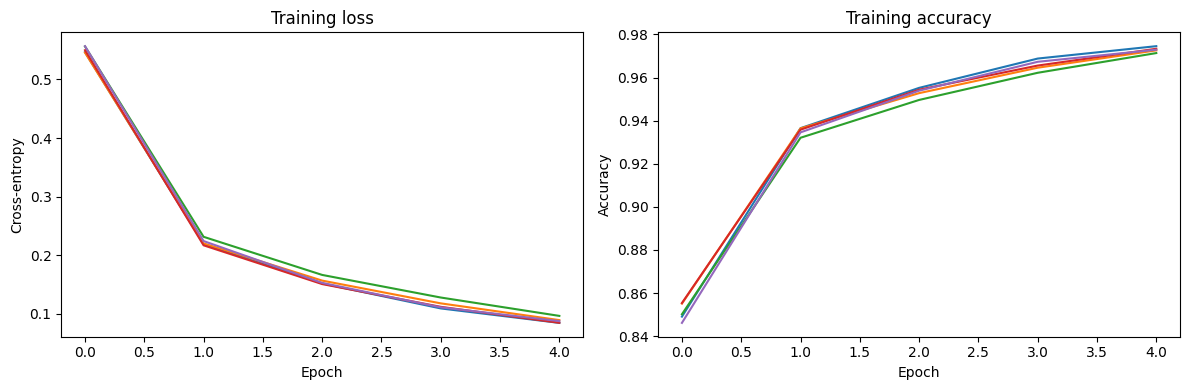

In [57]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for hist in cls_histories:
    plt.plot(hist["loss"])
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")

plt.subplot(1,2,2)
for hist in cls_histories:
    plt.plot(hist["acc"])
plt.title("Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [58]:
single_results = []
for i, model in enumerate(cls_models):
    probs, y_test = predict_proba(model, test_loader)
    metrics = classification_metrics(probs, y_test)
    single_results.append(metrics)
    print(f"Model {i+1}: acc={metrics['accuracy']:.4f}, nll={metrics['nll']:.4f}, brier={metrics['brier']:.4f}")

ens_probs, y_test, member_probs = ensemble_predict_proba(cls_models, test_loader)
ens_metrics = classification_metrics(ens_probs, y_test)

print("\nEnsemble results on MNIST test set")
print(f"Accuracy : {ens_metrics['accuracy']:.4f}")
print(f"NLL      : {ens_metrics['nll']:.4f}")
print(f"Brier    : {ens_metrics['brier']:.4f}")
print(f"Entropy  : {ens_metrics['entropy_mean']:.4f}")

Model 1: acc=0.9678, nll=0.1075, brier=0.0491
Model 2: acc=0.9634, nll=0.1274, brier=0.0575
Model 3: acc=0.9646, nll=0.1216, brier=0.0566
Model 4: acc=0.9634, nll=0.1221, brier=0.0567
Model 5: acc=0.9646, nll=0.1224, brier=0.0561

Ensemble results on MNIST test set
Accuracy : 0.9694
NLL      : 0.1046
Brier    : 0.0484
Entropy  : 0.1287


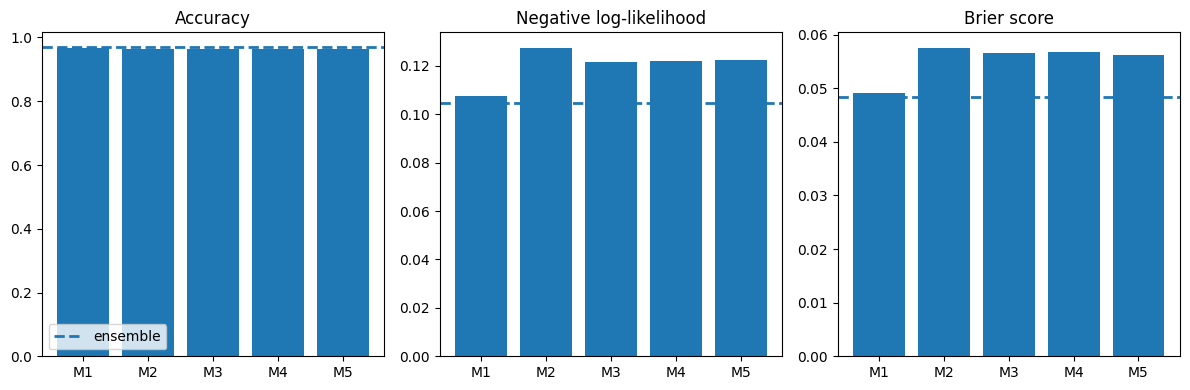

In [59]:
single_acc = [m["accuracy"] for m in single_results]
single_nll = [m["nll"] for m in single_results]
single_brier = [m["brier"] for m in single_results]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(np.arange(M_cls), single_acc)
plt.axhline(ens_metrics["accuracy"], linestyle="--", linewidth=2, label="ensemble")
plt.title("Accuracy")
plt.xticks(np.arange(M_cls), [f"M{i+1}" for i in range(M_cls)])
plt.legend()

plt.subplot(1,3,2)
plt.bar(np.arange(M_cls), single_nll)
plt.axhline(ens_metrics["nll"], linestyle="--", linewidth=2)
plt.title("Negative log-likelihood")
plt.xticks(np.arange(M_cls), [f"M{i+1}" for i in range(M_cls)])

plt.subplot(1,3,3)
plt.bar(np.arange(M_cls), single_brier)
plt.axhline(ens_metrics["brier"], linestyle="--", linewidth=2)
plt.title("Brier score")
plt.xticks(np.arange(M_cls), [f"M{i+1}" for i in range(M_cls)])

plt.tight_layout()
plt.show()

## Additional reproduction — Effect of ensemble size

### Comparison with the original paper

The original paper evaluates the effect of the ensemble size M on predictive performance and uncertainty metrics. Following the same idea, we evaluate ensembles of size M = 1, 3 and 5 on MN

In [60]:
ensemble_sizes = [1, 3, 5]

rows = []

for M in ensemble_sizes:
    selected_models = cls_models[:M]

    probs_M, y_test_M, _ = ensemble_predict_proba(
        selected_models,
        test_loader
    )

    metrics_M = classification_metrics(
        probs_M,
        y_test_M
    )

    rows.append({
        "M": M,
        "Accuracy": metrics_M["accuracy"],
        "Error": 1 - metrics_M["accuracy"],
        "NLL": metrics_M["nll"],
        "Brier": metrics_M["brier"]
    })

df_M = pd.DataFrame(rows)

df_M

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,M,Accuracy,Error,NLL,Brier
0,1,0.9678,0.0322,0.107511,0.049134
1,3,0.9698,0.0302,0.106638,0.048984
2,5,0.9694,0.0306,0.104625,0.048388


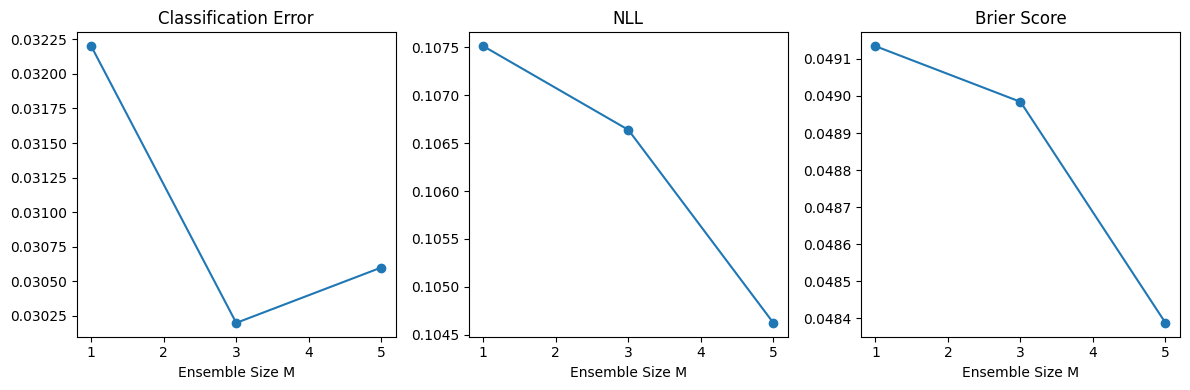

In [61]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(df_M["M"], df_M["Error"], marker="o")
plt.title("Classification Error")
plt.xlabel("Ensemble Size M")

plt.subplot(1,3,2)
plt.plot(df_M["M"], df_M["NLL"], marker="o")
plt.title("NLL")
plt.xlabel("Ensemble Size M")

plt.subplot(1,3,3)
plt.plot(df_M["M"], df_M["Brier"], marker="o")
plt.title("Brier Score")
plt.xlabel("Ensemble Size M")

plt.tight_layout()
plt.show()

# Part 3 — Predictive uncertainty

We compare predictive entropy on:

- normal MNIST test examples
- FashionMNIST as a proxy out-of-distribution dataset

Expected behavior:

- lower entropy on MNIST
- higher entropy on OOD data

In [62]:
ood_probs, _, _ = ensemble_predict_proba(cls_models, ood_loader)
ood_entropy = -np.sum(ood_probs * np.log(ood_probs + 1e-12), axis=1)
mnist_entropy = ens_metrics["entropy_per_sample"]

print("Mean entropy on MNIST test set       :", mnist_entropy.mean())
print("Mean entropy on FashionMNIST (OOD)   :", ood_entropy.mean())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Mean entropy on MNIST test set       : 0.1287096
Mean entropy on FashionMNIST (OOD)   : 0.6780384


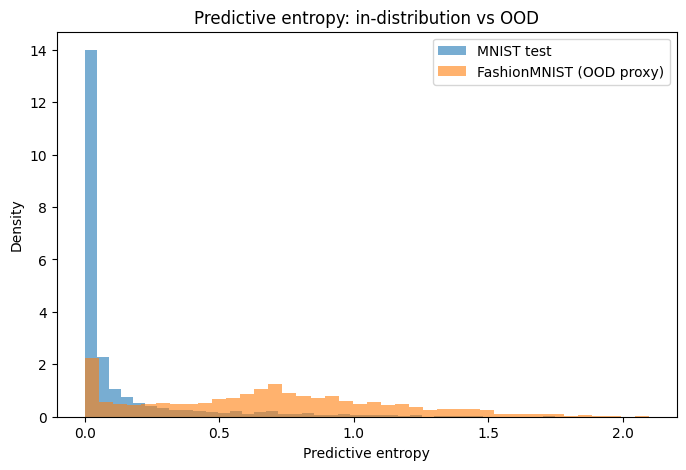

In [63]:
plt.figure(figsize=(8,5))
plt.hist(mnist_entropy, bins=40, alpha=0.6, density=True, label="MNIST test")
plt.hist(ood_entropy, bins=40, alpha=0.6, density=True, label="FashionMNIST (OOD proxy)")
plt.xlabel("Predictive entropy")
plt.ylabel("Density")
plt.title("Predictive entropy: in-distribution vs OOD")
plt.legend()
plt.show()

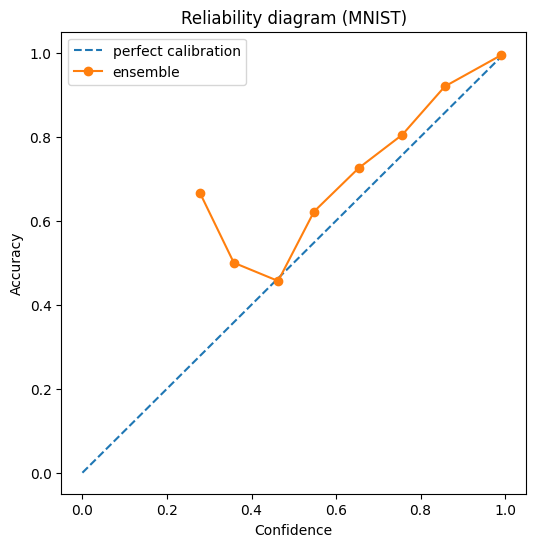

Approximate ECE: 0.01014601666331291


In [64]:
def reliability_bins(probs, y_true, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correctness = (predictions == y_true).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    bin_accs, bin_confs, counts = [], [], []
    for i in range(n_bins):
        left, right = bins[i], bins[i+1]
        mask = (confidences >= left) & (confidences <= right) if i == n_bins - 1 else (confidences >= left) & (confidences < right)
        if mask.sum() > 0:
            bin_accs.append(correctness[mask].mean())
            bin_confs.append(confidences[mask].mean())
            counts.append(mask.sum())
    return np.array(bin_accs), np.array(bin_confs), np.array(counts)

accs, confs, counts = reliability_bins(ens_probs, y_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], linestyle="--", label="perfect calibration")
plt.plot(confs, accs, marker="o", label="ensemble")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability diagram (MNIST)")
plt.legend()
plt.show()

ece = np.sum((counts / counts.sum()) * np.abs(accs - confs))
print("Approximate ECE:", float(ece))

# Final notes

I reproduced several of the paper's core ideas and experimental results:

1. **Toy regression uncertainty experiment** using deep ensembles
2. **MNIST deep ensemble classification experiment**
3. **Predictive uncertainty analysis** through entropy on in-distribution and out-of-distribution data
4. **Effect of ensemble size** on classification error, negative log-likelihood (NLL), and Brier score

These experiments reproduce the central methodology of the paper: training multiple independently initialized neural networks and combining their predictions to improve predictive performance and uncertainty estimation.
